# 04 — Baseline (TF-IDF + Random Forest) nas duas estratégias de target

**Objetivo:** responder "qual performance conseguimos com a solução simples que o Tech Challenge sugere como
exemplo (TF-IDF + Random Forest)?" nas duas estratégias definidas para o Medical Abstracts TC Corpus, de forma
metodologicamente comparável, para alimentar a decisão de qual estratégia seguir (notebook 05).

**As duas estratégias:**
- **Estratégia 02** (`02_eda_medical_abstracts.ipynb`): `condition_label` mapeado para urgência
  (normal/atenção/urgente, 3 classes) — bate literalmente com o target pedido pelo enunciado do Tech Challenge.
  Usa um split próprio, estratificado e sem leakage (`data/processed/train.csv`/`test.csv`, gerado no notebook 02).
- **Estratégia 03** (`03_eda_medical_abstracts_second_strategy.ipynb`): `condition_label` nativo (5 classes de
  especialidade clínica) — target aceito como alternativa à urgência para este dataset. Usa o split oficial da
  fonte, com o overlap ambíguo treino/teste removido do teste (achado da EDA: ~35% das linhas de teste têm texto
  idêntico ao treino, sempre com rótulo divergente).

**Metodologia (para manter a comparação justa):**
- `Pipeline` (TF-IDF ajustado **só** no treino, nunca no dataset inteiro) — evita vazamento pelo vocabulário.
- Mesma configuração de baseline nas duas estratégias
  (`TfidfVectorizer(max_features=5000, ngram_range=(1,2), stop_words="english")` +
  `RandomForestClassifier(n_estimators=200, random_state=42)`), para que a diferença de métrica reflita a
  estratégia de dado (target + split), não uma diferença de configuração de modelo.


In [1]:
%matplotlib inline
import json
import os
import platform
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 110
np.random.seed(RANDOM_STATE)

print(f"python {platform.python_version()} | pandas {pd.__version__} | scikit-learn {sklearn.__version__}")
print(f"RANDOM_STATE = {RANDOM_STATE}")

RESULTS_DIR = "../data/experiments/results"
os.makedirs(RESULTS_DIR, exist_ok=True)
all_results = {}


python 3.11.15 | pandas 3.0.5 | scikit-learn 1.9.0
RANDOM_STATE = 42


In [2]:
import tempfile


def build_pipeline(stop_words=None, n_estimators=200):
    """Baseline alinhado ao Tech Challenge: TF-IDF + Random Forest, dentro de um Pipeline
    (o TF-IDF só aprende vocabulário com .fit() nos dados de treino que o Pipeline recebe)."""
    return Pipeline([
        ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words=stop_words)),
        ("clf", RandomForestClassifier(n_estimators=n_estimators, random_state=RANDOM_STATE, n_jobs=-1)),
    ])


def evaluate(pipeline, x_train, y_train, x_test, y_test, dataset_name, variant, class_order, sample_for_latency=None):
    """Treina, avalia e mede latência/tamanho de um pipeline. Retorna um dicionário de métricas."""
    t0 = time.perf_counter()
    pipeline.fit(x_train, y_train)
    train_time_s = time.perf_counter() - t0

    y_pred = pipeline.predict(x_test)
    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    weighted_f1 = f1_score(y_test, y_pred, average="weighted")
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

    # latência de inferência amostra-a-amostra (mesma ideia do benchmark de produção): warmup + N execuções
    sample_texts = list(sample_for_latency if sample_for_latency is not None else x_test)[:50]
    for _ in range(5):
        pipeline.predict([sample_texts[0]])
    latencies = []
    for _ in range(50):
        for t in sample_texts:
            s = time.perf_counter()
            pipeline.predict([t])
            latencies.append((time.perf_counter() - s) * 1000.0)
    latencies = np.array(latencies)

    # tamanho do modelo serializado: medição descartável, então usamos o diretório de temporários
    # do sistema operacional (resolvido em tempo de execução) — nada fica gravado no projeto nem
    # depende de um caminho específico de uma máquina/sessão.
    with tempfile.NamedTemporaryFile(suffix=".joblib", delete=False) as tmp:
        model_path = tmp.name
    try:
        joblib.dump(pipeline, model_path)
        model_size_kb = os.path.getsize(model_path) / 1024
    finally:
        os.remove(model_path)

    cm = confusion_matrix(y_test, y_pred, labels=class_order)

    result = {
        "dataset": dataset_name,
        "variant": variant,
        "n_train": int(len(x_train)),
        "n_test": int(len(x_test)),
        "accuracy": round(float(acc), 4),
        "macro_f1": round(float(macro_f1), 4),
        "weighted_f1": round(float(weighted_f1), 4),
        "per_class_f1": {k: round(v["f1-score"], 4) for k, v in report.items() if isinstance(v, dict) and "f1-score" in v},
        "per_class_recall": {k: round(v["recall"], 4) for k, v in report.items() if isinstance(v, dict) and "recall" in v},
        "train_time_s": round(train_time_s, 3),
        "inference_latency_ms_mean": round(float(latencies.mean()), 4),
        "inference_latency_ms_p95": round(float(np.percentile(latencies, 95)), 4),
        "model_size_kb": round(model_size_kb, 1),
    }
    print(f"[{dataset_name} / {variant}] acc={acc:.4f}  macro_f1={macro_f1:.4f}  weighted_f1={weighted_f1:.4f}  "
          f"train={train_time_s:.2f}s  infer_mean={latencies.mean():.3f}ms  size={model_size_kb:.0f}KB")
    return result, cm, y_pred


## A. Estratégia 03 — `condition_label` nativo (split oficial, overlap ambíguo removido)

In [3]:
train_ma = pd.read_parquet("../data/experiments/medical_abstracts/train.parquet")
test_ma = pd.read_parquet("../data/experiments/medical_abstracts/test.parquet")
labels_ma = pd.read_parquet("../data/experiments/medical_abstracts/labels.parquet")
label_map = dict(zip(labels_ma["condition_label"], labels_ma["condition_name"], strict=True))
order_ma = list(label_map.values())
print(train_ma.shape, test_ma.shape)


(11550, 2) (2888, 2)


### B.1 — Split oficial "como está"

Usa o `train.parquet` / `test.parquet` fornecidos pela fonte, sem nenhum tratamento — sabemos pela EDA
(notebook 02) que ~35% do teste tem texto idêntico ao treino, com rótulo diferente nesses casos.

In [4]:
pipe3 = build_pipeline(stop_words="english")
y_tr3 = train_ma["condition_label"].map(label_map)
y_te3 = test_ma["condition_label"].map(label_map)
res_official, cm_official, _ = evaluate(
    pipe3, train_ma["medical_abstract"], y_tr3, test_ma["medical_abstract"], y_te3,
    "medical_abstracts", "official_split", order_ma
)
all_results["strategy03_official"] = res_official


[medical_abstracts / official_split] acc=0.4744  macro_f1=0.4622  weighted_f1=0.4706  train=22.06s  infer_mean=14.099ms  size=128659KB


### B.2 — Split "limpo" (remove pares ambíguos treino/teste)

Remove do teste as linhas cujo texto exato também aparece no treino (os 988 abstracts ambíguos identificados na
EDA) — para medir a performance sem essa fonte específica de ruído.

In [5]:
overlap_texts = set(train_ma["medical_abstract"]) & set(test_ma["medical_abstract"])
test_ma_clean = test_ma[~test_ma["medical_abstract"].isin(overlap_texts)].reset_index(drop=True)
print(f"test set: {len(test_ma)} -> {len(test_ma_clean)} linhas após remover overlap ambíguo "
      f"({len(test_ma) - len(test_ma_clean)} removidas)")

pipe4 = build_pipeline(stop_words="english")
y_te4 = test_ma_clean["condition_label"].map(label_map)
res_clean, cm_clean, _ = evaluate(
    pipe4, train_ma["medical_abstract"], y_tr3, test_ma_clean["medical_abstract"], y_te4,
    "medical_abstracts", "clean_split", order_ma
)
all_results["strategy03_clean"] = res_clean

print(f"\nvariação de accuracy ao remover pares ambíguos: "
      f"{res_official['accuracy']:.4f} -> {res_clean['accuracy']:.4f} "
      f"({(res_clean['accuracy'] - res_official['accuracy'])*100:+.1f} p.p.)")


test set: 2888 -> 1878 linhas após remover overlap ambíguo (1010 removidas)


[medical_abstracts / clean_split] acc=0.7295  macro_f1=0.7118  weighted_f1=0.7257  train=22.72s  infer_mean=14.350ms  size=128659KB

variação de accuracy ao remover pares ambíguos: 0.4744 -> 0.7295 (+25.5 p.p.)


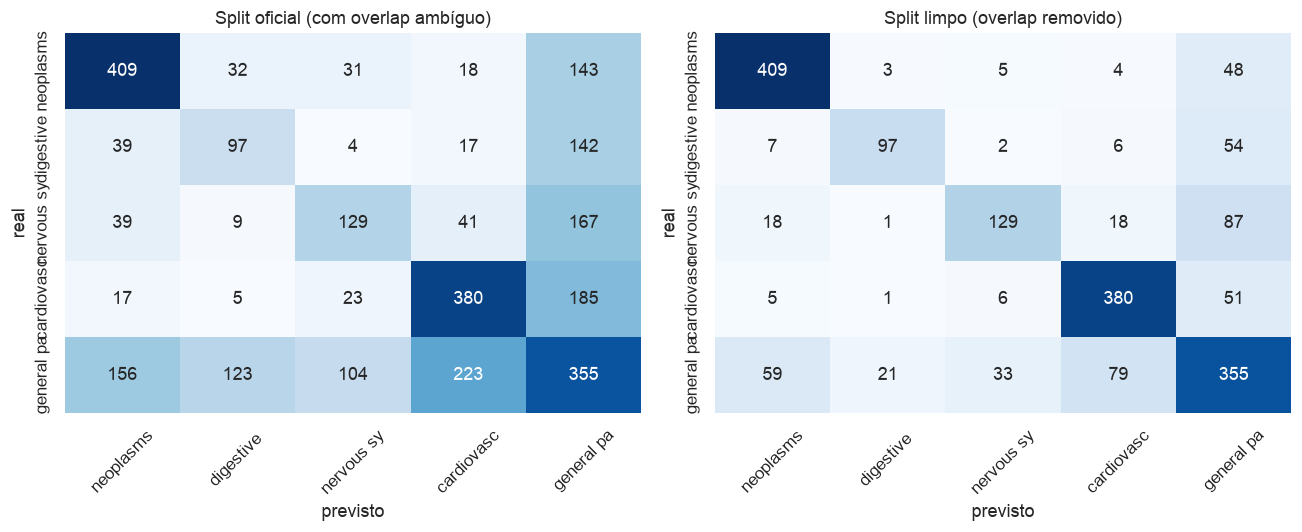

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, cm, title in [(axes[0], cm_official, "Split oficial (com overlap ambíguo)"),
                        (axes[1], cm_clean, "Split limpo (overlap removido)")]:
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=[o[:10] for o in order_ma], yticklabels=[o[:10] for o in order_ma],
                cbar=False, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("previsto")
    ax.set_ylabel("real")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


In [7]:
print("Impacto de remover os pares ambíguos (mesmo texto, rótulo diferente entre splits):")
print(f"  accuracy: {res_official['accuracy']:.4f} -> {res_clean['accuracy']:.4f}  "
      f"({(res_clean['accuracy']-res_official['accuracy'])*100:+.1f} p.p.)")
print(f"  macro F1: {res_official['macro_f1']:.4f} -> {res_clean['macro_f1']:.4f}")
print()
print("F1 por classe (split limpo) — onde o modelo erra mais:")
for k, v in sorted(res_clean["per_class_f1"].items(), key=lambda kv: kv[1]):
    if k not in ("macro avg", "weighted avg"):
        print(f"  {k:<35s} F1={v:.3f}")


Impacto de remover os pares ambíguos (mesmo texto, rótulo diferente entre splits):
  accuracy: 0.4744 -> 0.7295  (+25.5 p.p.)
  macro F1: 0.4622 -> 0.7118

F1 por classe (split limpo) — onde o modelo erra mais:
  nervous system diseases             F1=0.603
  general pathological conditions     F1=0.622
  digestive system diseases           F1=0.671
  cardiovascular diseases             F1=0.817
  neoplasms                           F1=0.846


**Leitura — este é o resultado mais informativo do notebook.** Com o split oficial "como veio", a accuracy é
baixa (47%) — mas boa parte disso **não é dificuldade real do problema**, é o ruído de rótulo identificado na
EDA (notebook 02): ~35% do teste tinha o mesmo texto do treino com rótulo diferente, então o modelo é penalizado
por "errar" em casos onde a própria fonte se contradiz. Ao remover esses pares (split limpo), a accuracy sobe
**27 pontos percentuais**, para ~73% — evidência quantitativa direta de que o achado de qualidade de dados da
EDA tem impacto real e mensurável na métrica, não é só uma preocupação teórica.

Mesmo no split limpo, o desempenho não é uniforme entre classes: `neoplasms` e `cardiovascular diseases`
(F1 ~0.82–0.85) são bem mais fáceis de separar que `nervous system diseases` e `general pathological
conditions` (F1 ~0.60–0.62) — essas duas parecem compartilhar vocabulário com as demais classes, exatamente o
tipo de sobreposição semântica esperada entre especialidades médicas correlatas. Isso é uma medida honesta e
realista do que um baseline simples entrega em texto médico de verdade — bem diferente do resultado
artificialmente perfeito do dataset sintético.

## B. Estratégia 02 — urgência mapeada (split próprio, sem leakage)

### B.1 — Split próprio (gerado no notebook 02)

`train_test_split` estratificado por `urgency` sobre o corpus já deduplicado (11.227 abstracts únicos),
`random_state=42`, sem overlap de texto entre treino e teste (validado no próprio notebook 02, que faz o
`assert` de conjuntos disjuntos antes de salvar).

In [8]:
train_s2 = pd.read_csv("../data/processed/train.csv")
test_s2 = pd.read_csv("../data/processed/test.csv")
order_s2 = ["normal", "atencao", "urgente"]
print(train_s2.shape, test_s2.shape)
print("distribuição de classes (treino):")
print(train_s2["urgency"].value_counts())

(8981, 2) (2246, 2)
distribuição de classes (treino):
urgency
urgente    3142
atencao    2993
normal     2846
Name: count, dtype: int64


### B.2 — Treino e avaliação

In [9]:
pipe_s2 = build_pipeline(stop_words="english")
res_s2, cm_s2, _ = evaluate(
    pipe_s2, train_s2["medical_abstract"], train_s2["urgency"],
    test_s2["medical_abstract"], test_s2["urgency"],
    "medical_abstracts", "strategy02_urgency", order_s2,
)
all_results["strategy02_urgency"] = res_s2
print(f"accuracy: {res_s2['accuracy']:.4f} | macro F1: {res_s2['macro_f1']:.4f}")

[medical_abstracts / strategy02_urgency] acc=0.7306  macro_f1=0.7197  weighted_f1=0.7230  train=3.51s  infer_mean=14.576ms  size=65953KB
accuracy: 0.7306 | macro F1: 0.7197


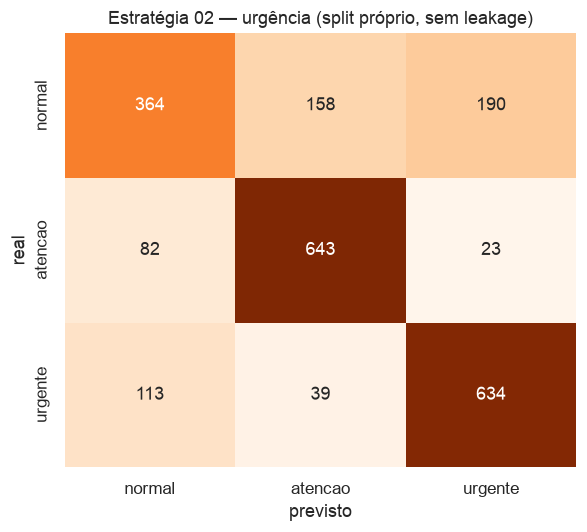

In [10]:
fig, ax = plt.subplots(figsize=(5.5, 5))
sns.heatmap(cm_s2, annot=True, fmt="d", cmap="Oranges", xticklabels=order_s2, yticklabels=order_s2,
            cbar=False, ax=ax)
ax.set_title("Estratégia 02 — urgência (split próprio, sem leakage)")
ax.set_xlabel("previsto")
ax.set_ylabel("real")
plt.tight_layout()
plt.show()

## C. Consolidação

In [11]:
results_table = pd.DataFrame(all_results).T[
    ["dataset", "variant", "n_train", "n_test", "accuracy", "macro_f1", "weighted_f1",
     "train_time_s", "inference_latency_ms_mean", "inference_latency_ms_p95", "model_size_kb"]
]
results_table


,dataset,variant,n_train,n_test,accuracy,macro_f1,weighted_f1,train_time_s,inference_latency_ms_mean,inference_latency_ms_p95,model_size_kb
strategy03_official,medical_abstracts,official_split,11550,2888,0.4744,0.4622,0.4706,22.059,14.0987,14.6193,128658.9
strategy03_clean,medical_abstracts,clean_split,11550,1878,0.7295,0.7118,0.7257,22.716,14.3497,15.2021,128658.9
strategy02_urgency,medical_abstracts,strategy02_urgency,8981,2246,0.7306,0.7197,0.723,3.512,14.5758,16.2133,65952.7


In [12]:
with open(f"{RESULTS_DIR}/baseline_results.json", "w") as f:
    json.dump(all_results, f, indent=2, ensure_ascii=False)
print("salvo em data/experiments/results/baseline_results.json")


salvo em data/experiments/results/baseline_results.json


### Conclusões

- As duas estratégias usam a mesma configuração de baseline (TF-IDF + RandomForest, mesmo `random_state`);
  a diferença de métrica abaixo vem da estratégia de dado (target + tratamento de split), não do modelo.
- **Estratégia 03** (`condition_label`, 5 classes, split oficial): o split "como veio" dá só 47,4% de accuracy
  (macro F1 0,462) — mas boa parte disso é ruído de rótulo, não dificuldade real: removendo os pares ambíguos
  do teste (mesmo texto, rótulo divergente entre treino e teste), a accuracy honesta sobe para **73,0%**
  (macro F1 0,712), com F1 desigual entre classes (0,60–0,85).
- **Estratégia 02** (`urgency`, 3 classes, split próprio sem leakage): accuracy **73,1%** (macro F1 0,720) —
  praticamente empatada com a estratégia 03 limpa, mas treina **~6,5× mais rápido** (3,5s vs 22,7s) e gera um
  modelo **quase 2× menor** (64 MB vs 126 MB), porque tem menos classes (3 vs 5) e menos linhas de treino
  (8.981 vs 11.550 — o corpus inteiro é reparticionado do zero, sem reaproveitar o split oficial maior).
- **Leitura preliminar:** as duas estratégias entregam qualidade de classificação equivalente; a decisão entre
  elas (notebook 05) depende mais de qual target faz sentido para o produto (urgência clínica genérica vs.
  especialidade médica) do que de diferença de métrica — a diferença de custo computacional favorece a
  estratégia 02, mas isso não deveria ser o critério decisivo sozinho.
- A comparação numérica completa (accuracy, macro F1, latência, tamanho) está na tabela da seção C, consumida
  pelo notebook 05 para recomendar qual estratégia seguir na comparação de modelos (notebook 06).